In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

In [2]:
train_df = pd.read_csv('data/채널정보_with_segment.csv')

In [3]:
train_df.info()
train_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Columns: 106 entries, 기준년월 to Segment
dtypes: int64(98), object(8)
memory usage: 1.9+ GB


기준년월              0
ID                0
인입횟수_ARS_R6M      0
이용메뉴건수_ARS_R6M    0
인입일수_ARS_R6M      0
                 ..
홈페이지_금융건수_R6M     0
홈페이지_선결제건수_R6M    0
홈페이지_금융건수_R3M     0
홈페이지_선결제건수_R3M    0
Segment           0
Length: 106, dtype: int64

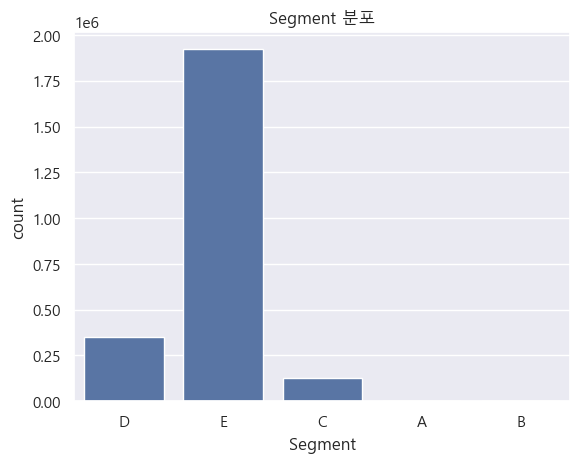

In [4]:
sns.countplot(data=train_df, x='Segment')
plt.title('Segment 분포')
plt.show()

In [5]:
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

In [6]:
# sns.boxplot(data=train_df, x='Segment', y='혜택수혜금액_R3M')

In [7]:
# sns.countplot(data=train_df, x='청구서발송여부_B0', hue='Segment')

In [8]:
from sklearn.preprocessing import LabelEncoder

train_df2 = train_df.copy()
le = LabelEncoder()
train_df2['Segment_encoded'] = le.fit_transform(train_df2['Segment'])


In [9]:
numeric_cols = train_df2.select_dtypes(include=['int64', 'float64']).columns.tolist()

corr_series = train_df2[numeric_cols].corrwith(train_df2['Segment_encoded']).sort_values(key=abs, ascending=False)
display(corr_series.head(20))


불만제기후경과월_R12M    -0.173899
방문후경과월_PC_R6M     0.172772
홈페이지_금융건수_R6M    -0.169264
방문월수_PC_R6M      -0.160520
홈페이지_금융건수_R3M    -0.160280
방문후경과월_앱_R6M      0.158202
인입일수_ARS_R6M     -0.156965
인입월수_ARS_R6M     -0.154813
방문횟수_앱_B0M       -0.154793
방문일수_앱_B0M       -0.152878
방문월수_앱_R6M       -0.152753
홈페이지_선결제건수_R6M   -0.151409
방문일수_앱_R6M       -0.149644
홈페이지_선결제건수_R3M   -0.148634
상담건수_R6M         -0.143577
인입월수_IB_R6M      -0.142631
인입일수_IB_R6M      -0.142005
방문일수_PC_B0M      -0.141835
방문횟수_PC_B0M      -0.141295
인입횟수_IB_R6M      -0.140527
dtype: float64

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1) + 1e-10)))

cat_cols = train_df.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Segment']

cramer_dict = {}
for col in cat_cols:
    try:
        cramer_dict[col] = cramers_v(train_df[col], train_df['Segment'])
    except:
        cramer_dict[col] = np.nan

cramer_series = pd.Series(cramer_dict).sort_values(ascending=False)
display(cramer_series.head(10))


ID                1.000000
인입횟수_ARS_R6M      0.110609
방문일수_PC_R6M       0.082484
방문횟수_앱_R6M        0.076309
방문횟수_PC_R6M       0.074717
이용메뉴건수_ARS_R6M    0.062729
OS구분코드            0.032469
dtype: float64

In [15]:
# 예: 수치형 중 절댓값 기준 0.2 이상
high_corr_num = corr_series[abs(corr_series) > 0.15].index.tolist()

# 범주형 중 Cramér’s V 기준 0.2 이상
high_corr_cat = cramer_series[cramer_series > 0.15].index.tolist()

# 최종 관심 컬럼
important_cols = high_corr_num + high_corr_cat
print("Segment와 관련 높은 컬럼:")
print(important_cols)


Segment와 관련 높은 컬럼:
['불만제기후경과월_R12M', '방문후경과월_PC_R6M', '홈페이지_금융건수_R6M', '방문월수_PC_R6M', '홈페이지_금융건수_R3M', '방문후경과월_앱_R6M', '인입일수_ARS_R6M', '인입월수_ARS_R6M', '방문횟수_앱_B0M', '방문일수_앱_B0M', '방문월수_앱_R6M', '홈페이지_선결제건수_R6M', 'ID']


In [12]:
results = []

for col in train_df2.columns:
    if col in ['Segment', 'Segment_encoded']:
        continue  # 타겟은 제외
    
    dtype = train_df2[col].dtype
    var_type = '수치형' if dtype in ['int64', 'float64'] else '범주형'

    # 상관계수 (수치형만 계산 가능)
    try:
        corr = train_df2[[col, 'Segment_encoded']].corr().iloc[0, 1] if var_type == '수치형' else None
    except:
        corr = None

    results.append({
        '컬럼명': col,
        '변수 타입': var_type,
        'Segment 상관계수': corr
    })

# 정렬 및 출력
result_df = pd.DataFrame(results).sort_values(by='Segment 상관계수', key=lambda x: x.abs() if x.name == 'Segment 상관계수' else x, ascending=False)
display(result_df.head(30))

,컬럼명,변수 타입,Segment 상관계수
93,불만제기후경과월_R12M,수치형,-0.173899
13,방문후경과월_PC_R6M,수치형,0.172772
101,홈페이지_금융건수_R6M,수치형,-0.169264
12,방문월수_PC_R6M,수치형,-0.160520
103,홈페이지_금융건수_R3M,수치형,-0.160280
17,방문후경과월_앱_R6M,수치형,0.158202
4,인입일수_ARS_R6M,수치형,-0.156965
5,인입월수_ARS_R6M,수치형,-0.154813
24,방문횟수_앱_B0M,수치형,-0.154793
25,방문일수_앱_B0M,수치형,-0.152878


In [13]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Cramér's V 함수 정의
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.shape[0] == 1 or confusion_matrix.shape[1] == 1:
        return np.nan  # 너무 적은 범주 제외
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1) + 1e-10)))

# 범주형 변수 리스트
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Segment']

# 결과 저장
cramer_results = []
for col in cat_cols:
    try:
        val = cramers_v(train_df[col], train_df['Segment'])
    except:
        val = np.nan
    cramer_results.append({'컬럼명': col, '변수 타입': '범주형', 'Cramér\'s V': val})

# 출력
cramer_df = pd.DataFrame(cramer_results).sort_values(by="Cramér's V", ascending=False)
display(cramer_df)


,컬럼명,변수 타입,Cramér's V
0,ID,범주형,1.000000
1,인입횟수_ARS_R6M,범주형,0.110609
4,방문일수_PC_R6M,범주형,0.082484
5,방문횟수_앱_R6M,범주형,0.076309
3,방문횟수_PC_R6M,범주형,0.074717
2,이용메뉴건수_ARS_R6M,범주형,0.062729
6,OS구분코드,범주형,0.032469


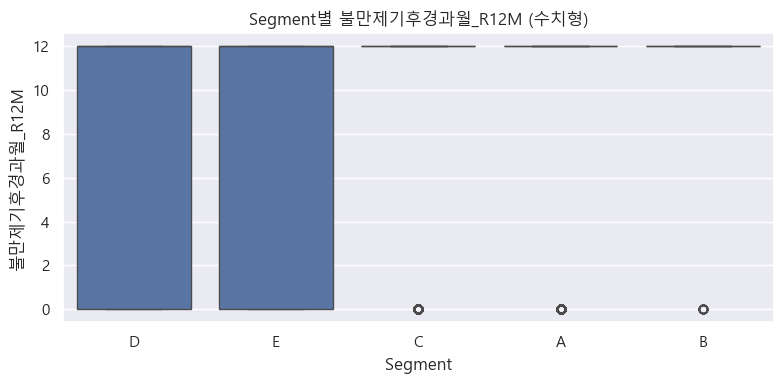

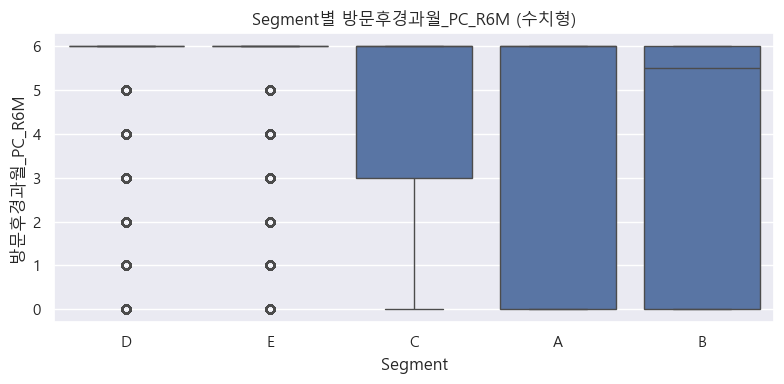

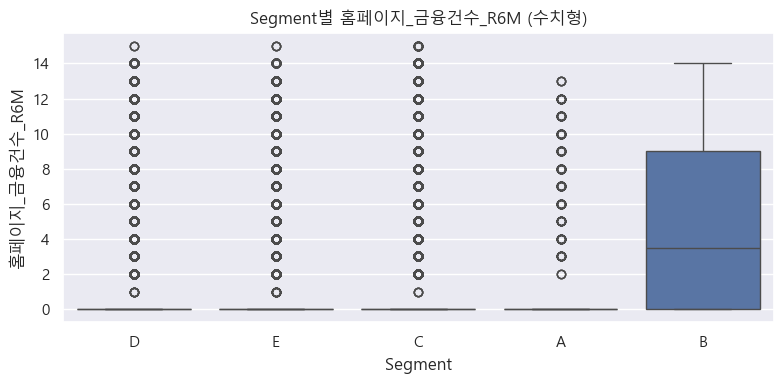

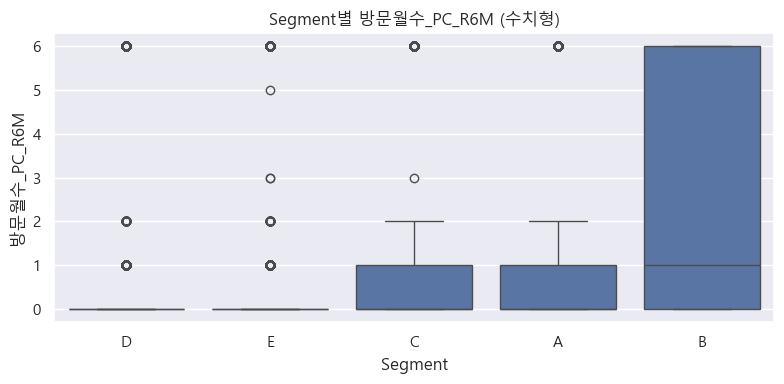

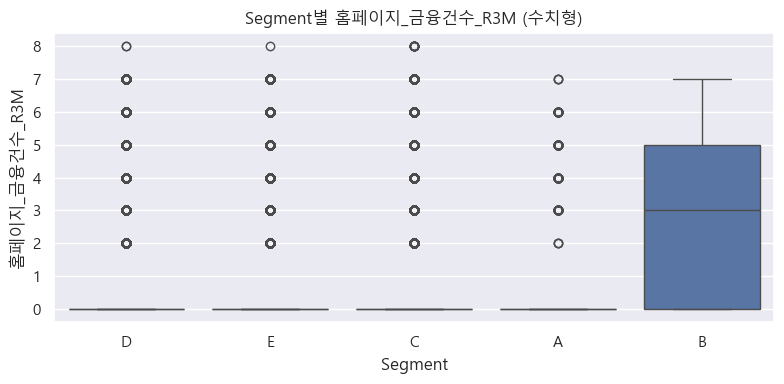

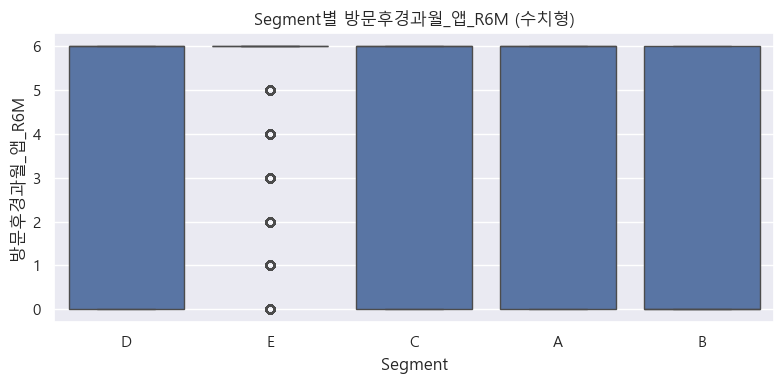

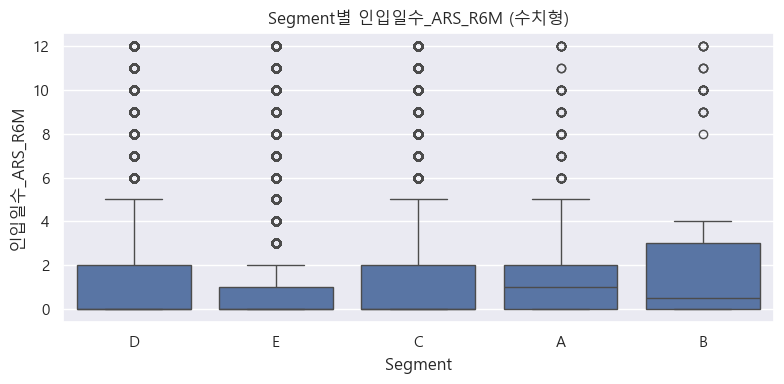

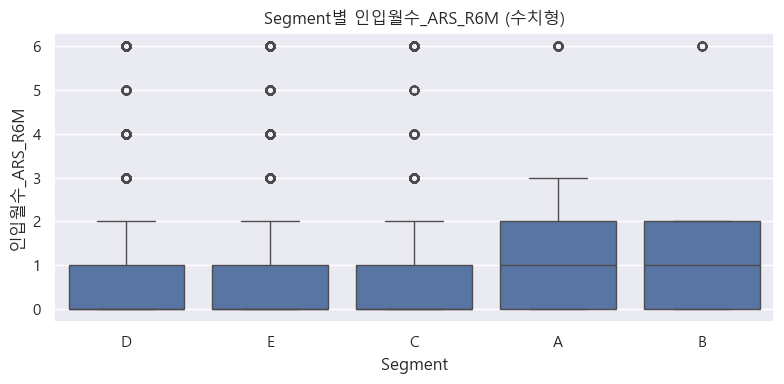

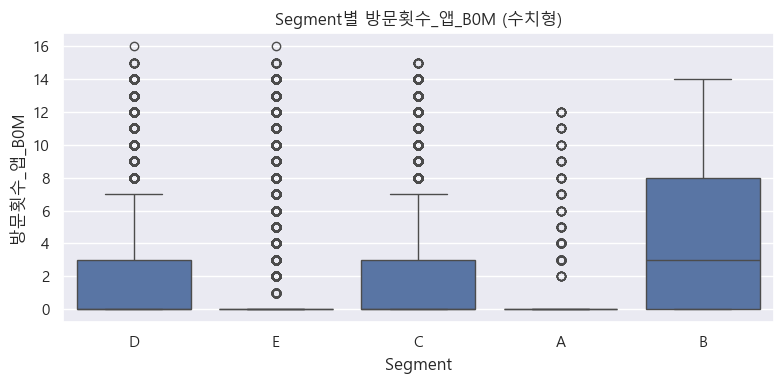

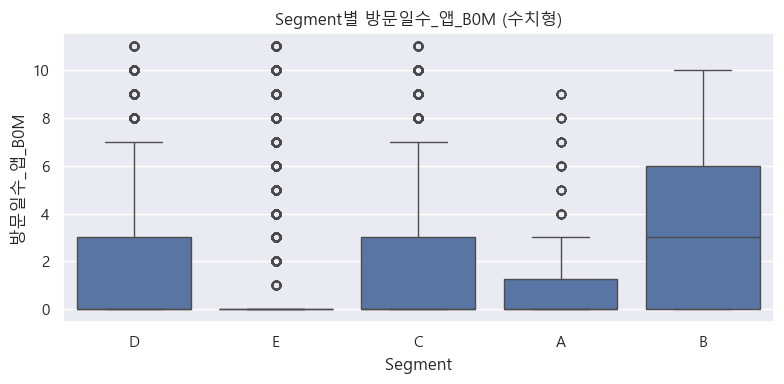

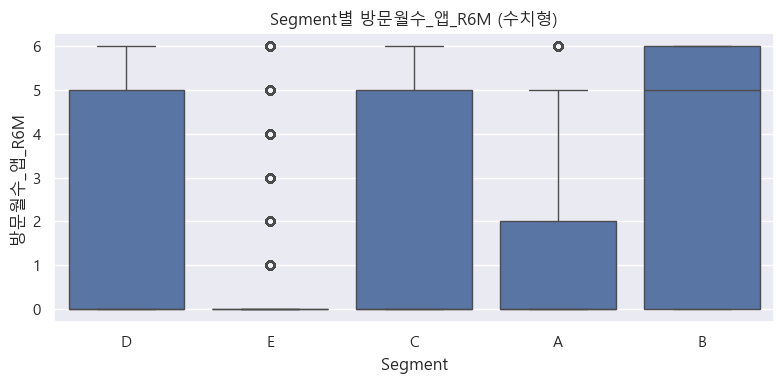

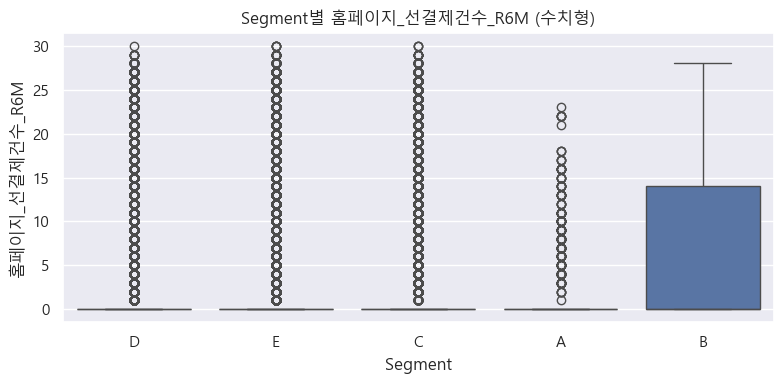

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Segment와 상관 높은 변수 리스트
important_cols = [
    '불만제기후경과월_R12M', '방문후경과월_PC_R6M', '홈페이지_금융건수_R6M', 
    '방문월수_PC_R6M', '홈페이지_금융건수_R3M', '방문후경과월_앱_R6M', 
    '인입일수_ARS_R6M', '인입월수_ARS_R6M', '방문횟수_앱_B0M', 
    '방문일수_앱_B0M', '방문월수_앱_R6M', '홈페이지_선결제건수_R6M'
]

# 수치형, 범주형 자동 분류
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = [col for col in important_cols if col not in numeric_cols]

# 시각화
for col in important_cols:
    plt.figure(figsize=(8, 4))
    
    if col in numeric_cols:
        # 수치형: boxplot
        sns.boxplot(data=train_df, x='Segment', y=col)
        plt.title(f'Segment별 {col} (수치형)')
    else:
        # 범주형: countplot
        sns.countplot(data=train_df, x=col, hue='Segment')
        plt.title(f'{col}별 Segment 분포 (범주형)')
        plt.xticks(rotation=30)
    
    plt.tight_layout()
    plt.show()
